In [1]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Titanic.csv')

In [3]:

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.shape

(891, 12)

In [5]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:

print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:

data['Age'].fillna(data['Age'].mean(), inplace=True)

In [8]:

data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

In [9]:

data.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)

In [10]:

print(data.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [11]:

survival_rate = data['Survived'].mean() * 100
print(f"نرخ بقای کلی مسافران: {survival_rate:.2f}%")

نرخ بقای کلی مسافران: 38.38%


In [12]:

gender_survival = data.groupby('Sex')['Survived'].mean() * 100
print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [13]:

class_survival = data.groupby('Pclass')['Survived'].mean() * 100
print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


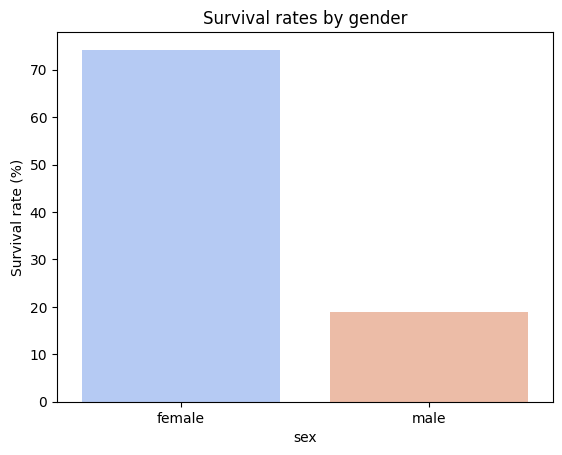

In [14]:

sns.barplot(x=gender_survival.index, y=gender_survival.values, palette='coolwarm')
plt.title('Survival rates by gender')
plt.ylabel('Survival rate (%)')
plt.xlabel('sex')
plt.show()

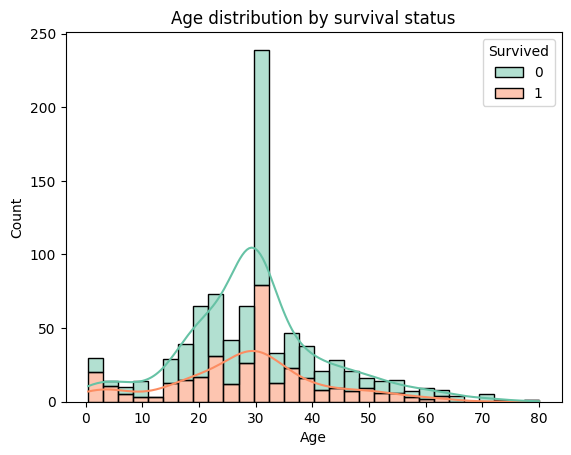

In [15]:
sns.histplot(data=data, x='Age', hue='Survived', bins=30, kde=True, multiple="stack", palette='Set2')
plt.title("Age distribution by survival status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


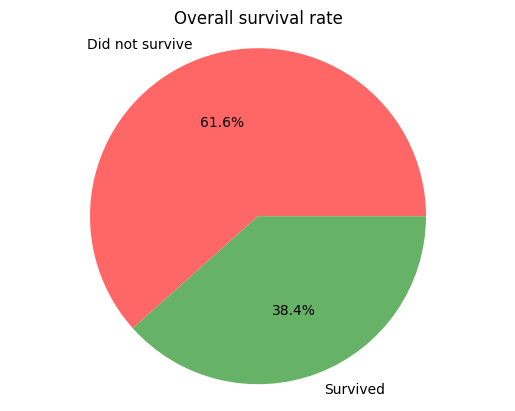

In [16]:
survival_counts = data['Survived'].value_counts()
labels = ['Did not survive', 'Survived']
colors = ['#ff6666', '#66b266']

plt.pie(survival_counts, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Overall survival rate")
plt.axis('equal')
plt.show()


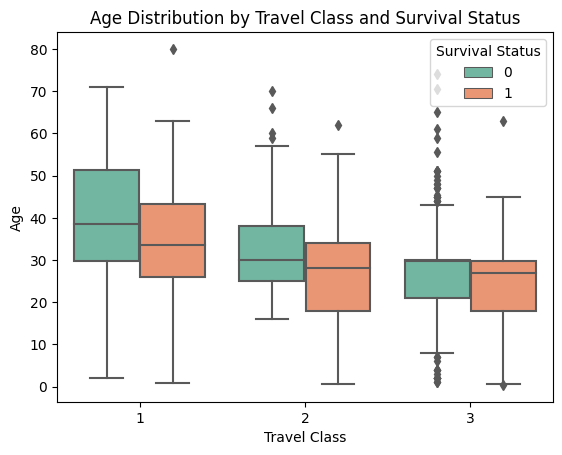

In [17]:

sns.boxplot(x='Pclass', y='Age', hue='Survived', data=data, palette='Set2')
plt.title('Age Distribution by Travel Class and Survival Status')
plt.xlabel('Travel Class')
plt.ylabel('Age')


plt.legend(title='Survival Status', loc='upper right') 
plt.show()


In [19]:
data['Survived'].mean()

0.3838383838383838

In [20]:
data.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [21]:
data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

(array([ 54.,  46., 177., 346., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

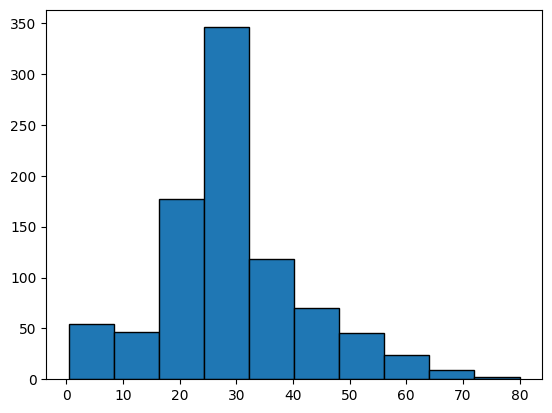

In [26]:
plt.hist(data['Age'],edgecolor='black')

<AxesSubplot: xlabel='Age', ylabel='Count'>

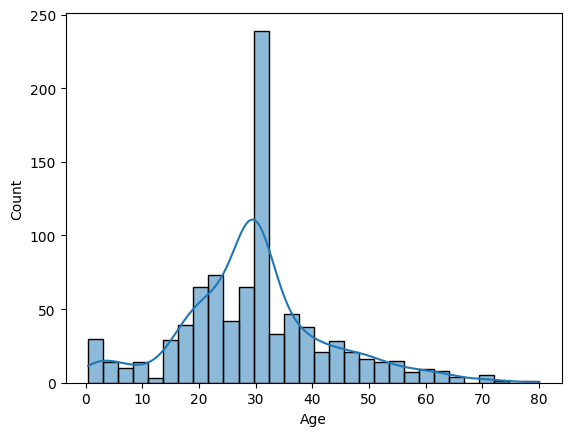

In [23]:
sns.histplot(data['Age'],kde=True)

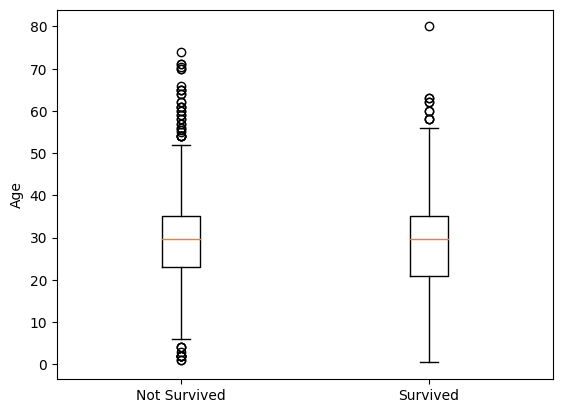

In [29]:
import matplotlib.pyplot as plt

data_to_plot = [
    data[data['Survived'] == 0]['Age'].dropna(),
    data[data['Survived'] == 1]['Age'].dropna()
]

plt.boxplot(data_to_plot)
plt.xticks([1,2], ['Not Survived', 'Survived'])
plt.ylabel('Age')
plt.show()


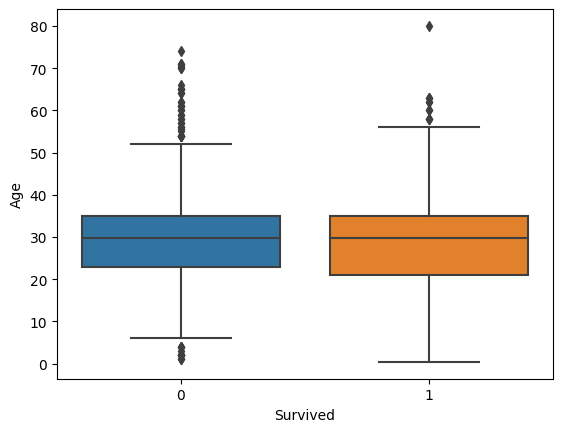

In [30]:
sns.boxplot(x='Survived', y='Age', data=data)
plt.show()

In [31]:
data['Embarked'].value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [32]:
data['FamilySize']=data['SibSp']+data['Parch']

In [33]:
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,1,0,3,male,22.000000,1,0,7.2500,S,1
1,2,1,1,female,38.000000,1,0,71.2833,C,1
2,3,1,3,female,26.000000,0,0,7.9250,S,0
3,4,1,1,female,35.000000,1,0,53.1000,S,1
4,5,0,3,male,35.000000,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S,0
887,888,1,1,female,19.000000,0,0,30.0000,S,0
888,889,0,3,female,29.699118,1,2,23.4500,S,3
889,890,1,1,male,26.000000,0,0,30.0000,C,0


<AxesSubplot: xlabel='FamilySize', ylabel='Survived'>

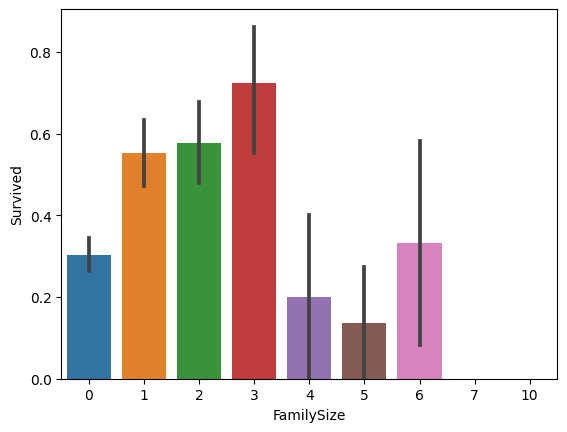

In [35]:
sns.barplot(x='FamilySize',y='Survived',data=data)

In [36]:
data['IsAlone']=(data['FamilySize']==0)
data.groupby('IsAlone')['Survived'].mean()

IsAlone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

<AxesSubplot: >

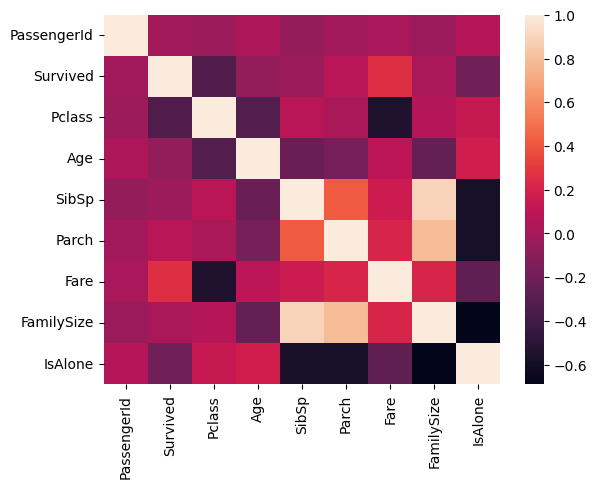

In [37]:
corr=data.corr(numeric_only=True)

sns.heatmap(corr)